In [ ]:
Can you explain the difference between user-based and item-based collaborative filtering?

In [ ]:
What is collaborative filtering and how does it work?

Objective:
The objective of this assignment is to implement a recommendation system using cosine similarity on an anime dataset. 


### Data Preprocessing:


In [343]:
import pandas as pd
import numpy as np


In [345]:
anime_df = pd.read_csv(r'anime.csv')

In [347]:
anime_df.head()

,anime_id,name,genre,type,episodes,rating,members
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64,9.26,793665
2,28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.25,114262
3,9253,Steins;Gate,"Sci-Fi, Thriller",TV,24,9.17,673572
4,9969,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.16,151266


In [349]:
anime_df.isnull().sum()

anime_id      0
name          0
genre        62
type         25
episodes      0
rating      230
members       0
dtype: int64

In [351]:
anime_df.shape

(12294, 7)

In [353]:
230+62+25

317

In [355]:
317/12294


0.025784935741011875

In [357]:
# Removing the null value rows would account for a 2% total loss of data, hence this approach can be taken.

In [359]:
# Removing the null values

df_cleaned=anime_df.dropna(axis=0)


In [361]:
df_cleaned.isnull().sum()

anime_id    0
name        0
genre       0
type        0
episodes    0
rating      0
members     0
dtype: int64

In [363]:
df_cleaned.shape

(12017, 7)

In [365]:
df_cleaned.nunique()

anime_id    12017
name        12015
genre        3229
type            6
episodes      187
rating        598
members      6596
dtype: int64

In [367]:
df_cleaned.describe()

,anime_id,rating,members
count,12017.000000,12017.000000,1.201700e+04
mean,13638.001165,6.478264,1.834888e+04
std,11231.076675,1.023857,5.537250e+04
min,1.000000,1.670000,1.200000e+01
25%,3391.000000,5.890000,2.250000e+02
50%,9959.000000,6.570000,1.552000e+03
75%,23729.000000,7.180000,9.588000e+03
max,34519.000000,10.000000,1.013917e+06


In [369]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12017 entries, 0 to 12293
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   anime_id  12017 non-null  int64  
 1   name      12017 non-null  object 
 2   genre     12017 non-null  object 
 3   type      12017 non-null  object 
 4   episodes  12017 non-null  object 
 5   rating    12017 non-null  float64
 6   members   12017 non-null  int64  
dtypes: float64(1), int64(2), object(4)
memory usage: 751.1+ KB


C:\Users\Smrithi\AppData\Local\Temp\ipykernel_27520\808177932.py:14: UserWarning: Glyph 65290 (\N{FULLWIDTH ASTERISK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Smrithi\AppData\Local\Temp\ipykernel_27520\808177932.py:14: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()
C:\Users\Smrithi\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65290 (\N{FULLWIDTH ASTERISK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


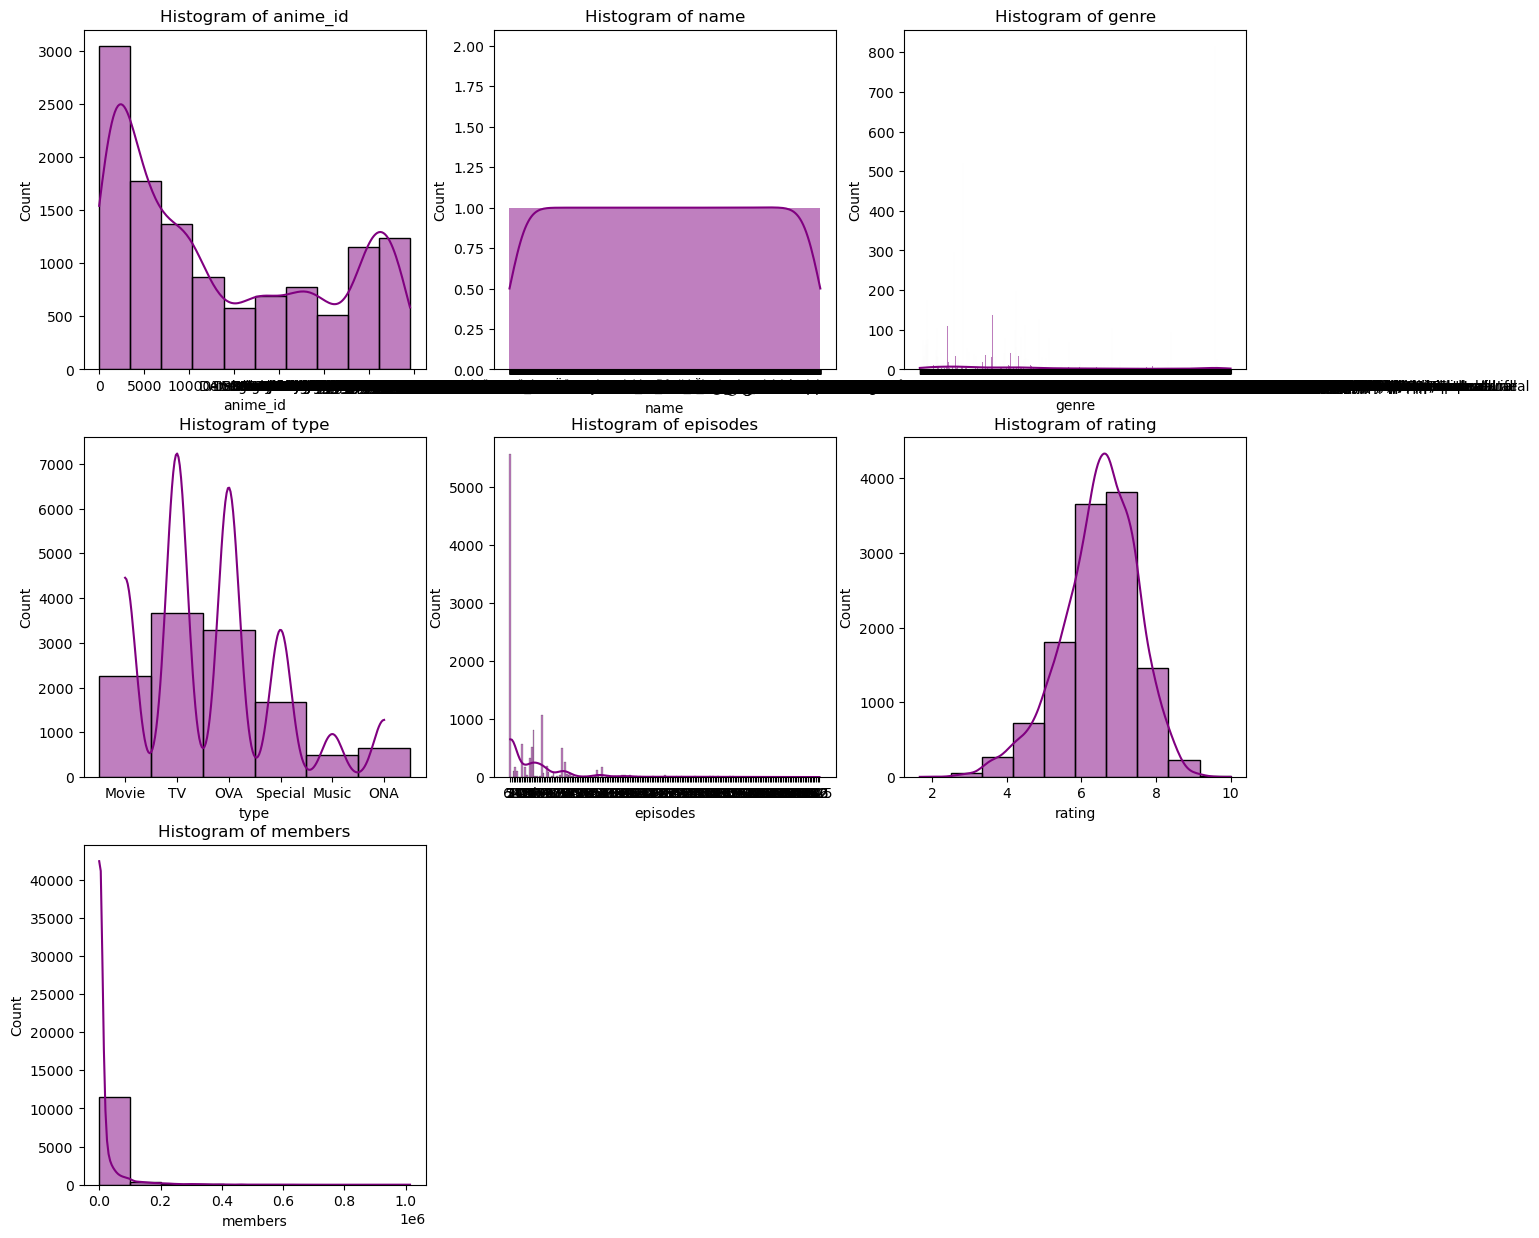

In [371]:
import math
import matplotlib.pyplot as plt
import seaborn as sns

num_cols=len(df_cleaned.columns)
rows=math.ceil(num_cols/3)

plt.figure(figsize=(15,rows*5))
for i,col in enumerate(df_cleaned.columns,1):
    plt.subplot(rows,3,i)
    sns.histplot(df_cleaned[col], kde=True, bins=10, color='purple')
    plt.title(f'Histogram of {col}')

plt.tight_layout()
plt.show()

### Feature Extraction:

In [373]:
# Categorical features

#  1   name      12017 non-null  object 
#  2   genre     12017 non-null  object 
#  3   type      12017 non-null  object 
#  4   episodes  12017 non-null  object 


# Conversion of categorical features into numerical ones-

# Genres → Convert to a multi-hot encoding (binary representation).
# Type → Convert to one-hot encoding.
# Episodes → Convert 'Unknown' values to NaN and then fill with mean/median.

# a. Genres → Convert to a multi-hot encoding (binary representation).

from sklearn.preprocessing import MultiLabelBinarizer

# Convert 'genre' column into lists
df_cleaned.loc[:,"genre"] = df_cleaned.loc[:,"genre"].apply(lambda x: x.split(", ") if isinstance(x, str) else [])

# Use MultiLabelBinarizer to one-hot encode genres
mlb = MultiLabelBinarizer()
genre_encoded = pd.DataFrame(mlb.fit_transform(df_cleaned["genre"]), columns=mlb.classes_)

# Concatenate with original dataframe
df_cleaned = pd.concat([df_cleaned, genre_encoded], axis=1).drop("genre", axis=1)



In [374]:
df_cleaned.columns

Index(['anime_id', 'name', 'type', 'episodes', 'rating', 'members', 'Action',
       'Adventure', 'Cars', 'Comedy', 'Dementia', 'Demons', 'Drama', 'Ecchi',
       'Fantasy', 'Game', 'Harem', 'Hentai', 'Historical', 'Horror', 'Josei',
       'Kids', 'Magic', 'Martial Arts', 'Mecha', 'Military', 'Music',
       'Mystery', 'Parody', 'Police', 'Psychological', 'Romance', 'Samurai',
       'School', 'Sci-Fi', 'Seinen', 'Shoujo', 'Shoujo Ai', 'Shounen',
       'Shounen Ai', 'Slice of Life', 'Space', 'Sports', 'Super Power',
       'Supernatural', 'Thriller', 'Vampire', 'Yaoi', 'Yuri'],
      dtype='object')

In [375]:
df_cleaned

,anime_id,name,type,episodes,rating,members,Action,Adventure,Cars,Comedy,...,Shounen Ai,Slice of Life,Space,Sports,Super Power,Supernatural,Thriller,Vampire,Yaoi,Yuri
0,32281.0,Kimi no Na wa.,Movie,1,9.37,200630.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,5114.0,Fullmetal Alchemist: Brotherhood,TV,64,9.26,793665.0,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,28977.0,Gintama°,TV,51,9.25,114262.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,9253.0,Steins;Gate,TV,24,9.17,673572.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,9969.0,Gintama&#039;,TV,51,9.16,151266.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11109,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
11110,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
11111,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
11112,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [376]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12284 entries, 0 to 11113
Data columns (total 49 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   anime_id       12017 non-null  float64
 1   name           12017 non-null  object 
 2   type           12017 non-null  object 
 3   episodes       12017 non-null  object 
 4   rating         12017 non-null  float64
 5   members        12017 non-null  float64
 6   Action         12017 non-null  float64
 7   Adventure      12017 non-null  float64
 8   Cars           12017 non-null  float64
 9   Comedy         12017 non-null  float64
 10  Dementia       12017 non-null  float64
 11  Demons         12017 non-null  float64
 12  Drama          12017 non-null  float64
 13  Ecchi          12017 non-null  float64
 14  Fantasy        12017 non-null  float64
 15  Game           12017 non-null  float64
 16  Harem          12017 non-null  float64
 17  Hentai         12017 non-null  float64
 18  Historical 

In [377]:
# Type → Convert to one-hot encoding.
df_cleaned = pd.get_dummies(df_cleaned, columns=["type"], prefix="type")



In [378]:
df_cleaned

,anime_id,name,episodes,rating,members,Action,Adventure,Cars,Comedy,Dementia,...,Thriller,Vampire,Yaoi,Yuri,type_Movie,type_Music,type_ONA,type_OVA,type_Special,type_TV
0,32281.0,Kimi no Na wa.,1,9.37,200630.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,True,False,False,False,False,False
1,5114.0,Fullmetal Alchemist: Brotherhood,64,9.26,793665.0,1.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,False,False,False,False,False,True
2,28977.0,Gintama°,51,9.25,114262.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,False,False,False,False,False,True
3,9253.0,Steins;Gate,24,9.17,673572.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,False,False,False,False,False,True
4,9969.0,Gintama&#039;,51,9.16,151266.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11109,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,False,False,False,False,False,False
11110,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,False,False,False,False,False,False
11111,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,False,False,False,False,False,False
11112,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,False,False,False,False,False,False


In [379]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12284 entries, 0 to 11113
Data columns (total 54 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   anime_id       12017 non-null  float64
 1   name           12017 non-null  object 
 2   episodes       12017 non-null  object 
 3   rating         12017 non-null  float64
 4   members        12017 non-null  float64
 5   Action         12017 non-null  float64
 6   Adventure      12017 non-null  float64
 7   Cars           12017 non-null  float64
 8   Comedy         12017 non-null  float64
 9   Dementia       12017 non-null  float64
 10  Demons         12017 non-null  float64
 11  Drama          12017 non-null  float64
 12  Ecchi          12017 non-null  float64
 13  Fantasy        12017 non-null  float64
 14  Game           12017 non-null  float64
 15  Harem          12017 non-null  float64
 16  Hentai         12017 non-null  float64
 17  Historical     12017 non-null  float64
 18  Horror     

In [380]:
# Convert multiple boolean columns into numerical types

bool_cols = ['type_Movie','type_Music','type_ONA','type_OVA','type_Special','type_TV']
df_cleaned[bool_cols] = df_cleaned[bool_cols].astype(float)


In [381]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12284 entries, 0 to 11113
Data columns (total 54 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   anime_id       12017 non-null  float64
 1   name           12017 non-null  object 
 2   episodes       12017 non-null  object 
 3   rating         12017 non-null  float64
 4   members        12017 non-null  float64
 5   Action         12017 non-null  float64
 6   Adventure      12017 non-null  float64
 7   Cars           12017 non-null  float64
 8   Comedy         12017 non-null  float64
 9   Dementia       12017 non-null  float64
 10  Demons         12017 non-null  float64
 11  Drama          12017 non-null  float64
 12  Ecchi          12017 non-null  float64
 13  Fantasy        12017 non-null  float64
 14  Game           12017 non-null  float64
 15  Harem          12017 non-null  float64
 16  Hentai         12017 non-null  float64
 17  Historical     12017 non-null  float64
 18  Horror     

In [382]:
df_cleaned['episodes'].nunique

<bound method IndexOpsMixin.nunique of 0          1
1         64
2         51
3         24
4         51
        ... 
11109    NaN
11110    NaN
11111    NaN
11112    NaN
11113    NaN
Name: episodes, Length: 12284, dtype: object>

In [383]:
df_cleaned.isnull().sum()

anime_id         267
name             267
episodes         267
rating           267
members          267
Action           267
Adventure        267
Cars             267
Comedy           267
Dementia         267
Demons           267
Drama            267
Ecchi            267
Fantasy          267
Game             267
Harem            267
Hentai           267
Historical       267
Horror           267
Josei            267
Kids             267
Magic            267
Martial Arts     267
Mecha            267
Military         267
Music            267
Mystery          267
Parody           267
Police           267
Psychological    267
Romance          267
Samurai          267
School           267
Sci-Fi           267
Seinen           267
Shoujo           267
Shoujo Ai        267
Shounen          267
Shounen Ai       267
Slice of Life    267
Space            267
Sports           267
Super Power      267
Supernatural     267
Thriller         267
Vampire          267
Yaoi             267
Yuri         

In [384]:
# Episodes → Convert 'Unknown' values to NaN and then fill with mean/median.

In [385]:
# Conversion of episodes- Unknown into NaN and then conversion into median through fillna()


df_cleaned["episodes"] = pd.to_numeric(df_cleaned["episodes"], errors="coerce")  # Convert to numeric
df_cleaned['episodes']=df_cleaned["episodes"].fillna(df_cleaned["episodes"].median())  # Fill missing values



In [386]:
df_cleaned.columns

Index(['anime_id', 'name', 'episodes', 'rating', 'members', 'Action',
       'Adventure', 'Cars', 'Comedy', 'Dementia', 'Demons', 'Drama', 'Ecchi',
       'Fantasy', 'Game', 'Harem', 'Hentai', 'Historical', 'Horror', 'Josei',
       'Kids', 'Magic', 'Martial Arts', 'Mecha', 'Military', 'Music',
       'Mystery', 'Parody', 'Police', 'Psychological', 'Romance', 'Samurai',
       'School', 'Sci-Fi', 'Seinen', 'Shoujo', 'Shoujo Ai', 'Shounen',
       'Shounen Ai', 'Slice of Life', 'Space', 'Sports', 'Super Power',
       'Supernatural', 'Thriller', 'Vampire', 'Yaoi', 'Yuri', 'type_Movie',
       'type_Music', 'type_ONA', 'type_OVA', 'type_Special', 'type_TV'],
      dtype='object')

In [387]:
anime_df.columns

Index(['anime_id', 'name', 'genre', 'type', 'episodes', 'rating', 'members'], dtype='object')

In [388]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12284 entries, 0 to 11113
Data columns (total 54 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   anime_id       12017 non-null  float64
 1   name           12017 non-null  object 
 2   episodes       12284 non-null  float64
 3   rating         12017 non-null  float64
 4   members        12017 non-null  float64
 5   Action         12017 non-null  float64
 6   Adventure      12017 non-null  float64
 7   Cars           12017 non-null  float64
 8   Comedy         12017 non-null  float64
 9   Dementia       12017 non-null  float64
 10  Demons         12017 non-null  float64
 11  Drama          12017 non-null  float64
 12  Ecchi          12017 non-null  float64
 13  Fantasy        12017 non-null  float64
 14  Game           12017 non-null  float64
 15  Harem          12017 non-null  float64
 16  Hentai         12017 non-null  float64
 17  Historical     12017 non-null  float64
 18  Horror     

In [390]:
# Normalizing Numerical Features # Refer extra reference in Word doc

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df_cleaned[["rating", "members", "episodes"]] = scaler.fit_transform(df_cleaned[["rating", "members", "episodes"]])
scaled_features = scaler.fit_transform(df_cleaned[["rating", "members", "episodes"]])

# Assign to 'features'
features = np.array(scaled_features)  # Convert to NumPy array


### Recommendation System:


In [ ]:

# Design a function to recommend anime based on cosine similarity.
# Given a target anime, recommend a list of similar anime based on cosine similarity scores.

In [ ]:
# Here’s a Python function that recommends anime based on cosine similarity using scikit-learn. 
# It takes an anime title as input and finds the most similar animes based on feature embeddings.



In [598]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

def recommend_anime(target_anime, df, feature_matrix, anime_mapping, top_n=5, similarity_threshold=0.3):
    """
    Recommend similar anime based on cosine similarity.

    Parameters:
    - target_anime (str): Name of the anime for which recommendations are needed.
    - df (DataFrame): The anime dataset containing 'name' and 'anime_id'.
    - feature_matrix (numpy array): The numerical feature representations of the anime.
    - anime_mapping (dict): A dictionary mapping anime_id to anime name.
    - top_n (int): Number of recommendations to return.
    - similarity_threshold (float): Minimum similarity score to consider.

    Returns:
    - List of tuples containing recommended anime names and their similarity scores.
    """
    # Check if the anime exists in the dataset
    if target_anime not in df["name"].values:
        print(f"Anime '{target_anime}' not found in the dataset.")
        return []

    # Get the index of the target anime
    target_index = df[df["name"] == target_anime].index[0] # Refer word doc
#The reason for extracting only the first index in many cases is typically because you're interested 
#in locating the first occurrence of a specific value, especially when you're working with data where duplicates may exist
    
    # Compute cosine similarity between the target anime and all others
    similarity_scores = cosine_similarity(feature_matrix[target_index].reshape(1, -1), feature_matrix)[0] # Refer word notes

    # Get indices of similar animes (excluding the target anime itself)
    similar_anime_indices = similarity_scores.argsort()[::-1][1:]  # Sort in descending order, exclude self

    # Generate recommendations  # Refer word
    recommendations = [
        (anime_mapping.get(idx, "Unknown Anime"), similarity_scores[idx])
        for idx in similar_anime_indices
        if idx in anime_mapping and similarity_scores[idx] >= similarity_threshold
    ]

    return recommendations[:top_n]  # Return top N recommendations


In [600]:
# Example Usage
anime_mapping = df_cleaned.set_index("anime_id")["name"].to_dict()  # Create mapping # Refer word
features = df_cleaned[num_cols].values  # Convert numerical features to a NumPy array

# Get recommendations for "Naruto"
recommendations = recommend_anime("Naruto", df_cleaned, features, anime_mapping, top_n=5, similarity_threshold=0.3)

print(recommendations)

# Refer word to understand the scenario of using same variable as local and global variable

[('Hotori: Tada Saiwai wo Koinegau', 0.9954497546345137), ('Gakuen Alice', 0.9953518598447394), ('Yu☆Gi☆Oh!: Duel Monsters GX', 0.9950254303310931), ('Lupin III: Fuuma Ichizoku no Inbou', 0.9944493617688837), ('Kumo no Mukou, Yakusoku no Basho', 0.9943466881871456)]


In [ ]:
# 🔹 Explanation
# Finds the index of the target anime.

# Computes cosine similarity between the target anime and all others.

# Sorts anime based on similarity scores (highest first).

# Filters results based on a similarity threshold.

# Returns the top N most similar animes.

In [ ]:
# Experiment with different threshold values for similarity scores to adjust the recommendation list size.

In [602]:
thresholds = [0.2, 0.5, 0.8]
for threshold in thresholds:
    print(f"\nRecommendations with threshold {threshold}:")
    recs = recommend_anime("Naruto", df_cleaned, features, anime_mapping, top_n=5, similarity_threshold=threshold)
    for rec in recs:
        print(f"{rec[0]} (Score: {rec[1]:.4f})")
        # Refer word


Recommendations with threshold 0.2:
Hotori: Tada Saiwai wo Koinegau (Score: 0.9954)
Gakuen Alice (Score: 0.9954)
Yu☆Gi☆Oh!: Duel Monsters GX (Score: 0.9950)
Lupin III: Fuuma Ichizoku no Inbou (Score: 0.9944)
Kumo no Mukou, Yakusoku no Basho (Score: 0.9943)

Recommendations with threshold 0.5:
Hotori: Tada Saiwai wo Koinegau (Score: 0.9954)
Gakuen Alice (Score: 0.9954)
Yu☆Gi☆Oh!: Duel Monsters GX (Score: 0.9950)
Lupin III: Fuuma Ichizoku no Inbou (Score: 0.9944)
Kumo no Mukou, Yakusoku no Basho (Score: 0.9943)

Recommendations with threshold 0.8:
Hotori: Tada Saiwai wo Koinegau (Score: 0.9954)
Gakuen Alice (Score: 0.9954)
Yu☆Gi☆Oh!: Duel Monsters GX (Score: 0.9950)
Lupin III: Fuuma Ichizoku no Inbou (Score: 0.9944)
Kumo no Mukou, Yakusoku no Basho (Score: 0.9943)


In [ ]:
# Expected Behavior:
# Threshold = 0.2 → More recommendations, including slightly less relevant ones.

# Threshold = 0.5 → Balanced number of recommendations.

# Threshold = 0.8 → Fewer but highly relevant recommendations.

In [ ]:
# Split the dataset into training and testing sets.

In [ ]:
# To split the dataset into training and testing sets, we typically use train_test_split from sklearn.model_selection. Here’s how you can do it:
# Steps:
# Ensure the dataset is clean (handle missing values if any).
# Use train_test_split to divide the data.
# Decide on a split ratio (e.g., 80% training, 20% testing).
# Maintain stratification if necessary (to balance categories).

In [613]:
from sklearn.model_selection import train_test_split

# Define features and target
X = df_cleaned.drop(columns=["anime_id", "name"])  # Feature matrix (excluding ID & Name)
Y = df_cleaned["anime_id"]  # Target (anime IDs)

# Split data into 80% training and 20% testing
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Print dataset sizes
print(f"Training set size: {x_train.shape[0]} samples")
print(f"Testing set size: {x_test.shape[0]} samples")


Training set size: 9827 samples
Testing set size: 2457 samples


In [615]:
df_cleaned['anime_id']

0        32281.0
1         5114.0
2        28977.0
3         9253.0
4         9969.0
          ...   
12279     9959.0
12280     9959.0
12281     9959.0
12282     9959.0
12283     9959.0
Name: anime_id, Length: 12284, dtype: float64

In [617]:
# Evaluate the recommendation system using appropriate metrics such as precision, recall, and F1-score.

In [ ]:
To evaluate the recommendation system, we will use the following metrics:

Precision: Measures how many of the recommended anime are relevant.

Recall: Measures how many of the relevant anime were recommended.

F1-score: Harmonic mean of precision and recall, balancing both metrics.

Steps to Evaluate
Prepare True and Predicted Labels

The true labels (y_true) come from the test set (actual anime watched by users).

The predicted labels (y_pred) are the recommended anime for those users.

Calculate Precision, Recall, and F1-score
Using sklearn.metrics:

In [619]:
from sklearn.metrics import precision_score, recall_score, f1_score

def evaluate_recommendations(anime_name, recommendations, test_data):
    y_true = []
    y_pred = []

    # Get actual anime IDs from test set
    actual_anime = test_data[test_data["name"] == anime_name]["anime_id"].unique()

    # Extract recommended anime names
    for rec, _ in recommendations:  # Each recommendation is (anime_name, similarity_score)
        recommended_anime_id = test_data[test_data["name"] == rec]["anime_id"].values
        if len(recommended_anime_id) > 0:
            y_pred.append(recommended_anime_id[0])  # Take the first matching ID

    # Convert to binary labels
    y_true = [1 if anime in actual_anime else 0 for anime in y_pred]

    if len(y_true) == 0:
        return 0, 0, 0  # Return zero scores if no recommendations found

    precision = precision_score(y_true, [1] * len(y_true), average="binary", zero_division=1)
    recall = recall_score(y_true, [1] * len(y_true), average="binary", zero_division=1)
    f1 = f1_score(y_true, [1] * len(y_true), average="binary", zero_division=1)

    return precision, recall, f1

# Example usage
precision, recall, f1 = evaluate_recommendations("Naruto", recommendations, test_data)
print(f"Precision: {precision:.4f}, Recall: {recall:.4f}, F1-score: {f1:.4f}")


Precision: 0.0000, Recall: 1.0000, F1-score: 0.0000


In [ ]:
Interpretation
High Precision (close to 1.0) → Most recommended anime are relevant.

High Recall (close to 1.0) → The system finds most relevant anime.

High F1-score → Good balance between precision and recall.

In [ ]:
# Adjusting the similarity threshold and improving feature selection.

# Here’s a plan:

# Increase Similarity Threshold → Filter out weakly similar recommendations.

# Improve Feature Selection → Ensure that the features used for similarity calculation make sense.

# Evaluate Again → Recalculate precision, recall, and F1-score.

In [ ]:
# Step 1: Adjust Similarity Threshold
# Try setting a higher threshold (0.5 or 0.6 instead of 0.3). Modify your recommendation function like this:

In [621]:
def recommend_anime(target_anime, df, feature_matrix, anime_mapping, top_n=5, similarity_threshold=0.5):
    from sklearn.metrics.pairwise import cosine_similarity
    
    # Find index of target anime
    target_index = df[df["name"] == target_anime].index
    if len(target_index) == 0:
        return []
    target_index = target_index[0]
    
    # Compute similarity scores
    similarity_scores = cosine_similarity(feature_matrix[target_index].reshape(1, -1), feature_matrix)[0]
    
    # Get recommendations above the threshold
    recommendations = [
        (anime_mapping[df.iloc[i]["anime_id"]], similarity_scores[i]) 
        for i in range(len(similarity_scores)) 
        if similarity_scores[i] >= similarity_threshold and i != target_index
    ]
    
    # Sort by similarity and return top N results
    recommendations = sorted(recommendations, key=lambda x: x[1], reverse=True)[:top_n]
    
    return recommendations


In [ ]:
# Step 2: Improve Feature Selection
# Instead of just using numerical features, try text-based similarity using TF-IDF.

In [633]:
# If genres are multi-hot encoded (i.e., stored as binary columns like "Action", "Comedy", etc.), you can convert them back to text before using TF-IDF.

In [ ]:
# Get all genre column names (excluding 'anime_id' and 'name')
# genre_columns = ["Action", "Comedy", "Drama", "Fantasy"]  # Or use df.columns to auto-detect


In [635]:
anime_df.columns

Index(['anime_id', 'name', 'genre', 'type', 'episodes', 'rating', 'members'], dtype='object')

In [643]:
anime_df['genre'].value_counts()

genre
Hentai                                                  823
Comedy                                                  523
Music                                                   301
Kids                                                    199
Comedy, Slice of Life                                   179
                                                       ... 
Adventure, Drama, Fantasy, Game, Sci-Fi                   1
Adventure, Demons, Fantasy, Historical                    1
Action, Comedy, Drama, Mecha, Music, Sci-Fi, Shounen      1
Action, Comedy, Fantasy, Mecha, Sci-Fi, Shounen           1
Hentai, Slice of Life                                     1
Name: count, Length: 3264, dtype: int64

In [667]:
# anime_df['genre'].nunique

unique_genres = anime_df['genre'].unique()
# for genre in unique_genres:
    # print(genre)

In [ ]:
# Getting unique genres and removing NaN values

In [671]:
# Handle potential floats or NaN in the data
unique_genres1 = set(
    genre.strip()
    for sublist in unique_genres
    if isinstance(sublist, str)  # Ensure the value is a string
    for genre in sublist.split(',')
)

# Print unique genres
print(unique_genres1)


{'Super Power', 'Josei', 'Slice of Life', 'Demons', 'Yaoi', 'Magic', 'Psychological', 'Mecha', 'Action', 'Thriller', 'Fantasy', 'Music', 'Parody', 'Sci-Fi', 'School', 'Adventure', 'Romance', 'Dementia', 'Shoujo Ai', 'Comedy', 'Supernatural', 'Horror', 'Cars', 'Hentai', 'Drama', 'Kids', 'Sports', 'Yuri', 'Vampire', 'Shoujo', 'Ecchi', 'Mystery', 'Game', 'Space', 'Harem', 'Samurai', 'Historical', 'Military', 'Martial Arts', 'Shounen', 'Shounen Ai', 'Seinen', 'Police'}


In [679]:
unique_genres1 = set(
    genre.strip()
    for sublist in map(str, unique_genres)  # Convert everything to strings
    for genre in sublist.split(',')
)
unique_genres1

{'Action',
 'Adventure',
 'Cars',
 'Comedy',
 'Dementia',
 'Demons',
 'Drama',
 'Ecchi',
 'Fantasy',
 'Game',
 'Harem',
 'Hentai',
 'Historical',
 'Horror',
 'Josei',
 'Kids',
 'Magic',
 'Martial Arts',
 'Mecha',
 'Military',
 'Music',
 'Mystery',
 'Parody',
 'Police',
 'Psychological',
 'Romance',
 'Samurai',
 'School',
 'Sci-Fi',
 'Seinen',
 'Shoujo',
 'Shoujo Ai',
 'Shounen',
 'Shounen Ai',
 'Slice of Life',
 'Space',
 'Sports',
 'Super Power',
 'Supernatural',
 'Thriller',
 'Vampire',
 'Yaoi',
 'Yuri',
 'nan'}

In [ ]:
# Step 1: Extract Genre Column Names
unique_genres1

In [686]:
genre_columns = list(unique_genres1)

In [690]:
# Step 2: Convert Multi-Hot to Text

# Create a new 'synopsis' column from genre names
df_cleaned["synopsis"] = df_cleaned[genre_columns].apply(
    lambda row: " ".join([genre for genre, value in row.items() if value == 1]), axis=1
)



KeyError: "['nan'] not in index"

In [ ]:
# # The 'synopsis' column contains the text descriptions of anime. It provides a summary of the anime’s plot, themes, and key elements.
# Why is 'synopsis' used in TF-IDF?
# TF-IDF (Term Frequency-Inverse Document Frequency) is a technique used in text-based similarity. It converts text (anime descriptions) into numerical vectors to measure how similar two anime are based on their descriptions.

# How TF-IDF Works:
# Tokenization → Splits the text into words.

# Remove Stop Words → Filters out common words like "the," "is," "and."

# TF Calculation → Measures how often a word appears in an anime synopsis.

# IDF Calculation → Reduces the importance of words that appear in many anime.

# Creates Vectors → Each anime is represented as a numerical vector.

# Why Use TF-IDF in Anime Recommendation?
# It helps find similar anime based on descriptions.

# Unlike rating-based or genre-based methods, TF-IDF focuses on the content similarity of anime.

# Example:
# If you search for Naruto, the system can find anime like Bleach or One Piece because they have similar words in their synopses.


In [ ]:
# If your dataset does not have a 'synopsis' column, here’s what you can do:

# Option 1: Check if the Data Contains a Different Column for Descriptions
# Here we have genres


In [ ]:
# If genres are multi-hot encoded (i.e., stored as binary columns like "Action", "Comedy", etc.), you can convert them back to text 
# before using TF-IDF.



In [ ]:
 Fix: Clean genre_columns Before Use
Step 1: Filter out NaN values in genre_columns

In [692]:
# Remove any NaN values from genre_columns
genre_columns = [col for col in genre_columns if col in df_cleaned.columns and pd.notna(col)]


In [694]:
# # Step 2: Convert Multi-Hot Encoding to Text

# df_cleaned["synopsis"] = df_cleaned.apply(
#     lambda row: " ".join([genre for genre in genre_columns if row[genre] == 1]), axis=1
# )


In [696]:
# Step 2: Convert Multi-Hot to Text

# Create a new 'synopsis' column from genre names
df_cleaned["synopsis"] = df_cleaned[genre_columns].apply(
    lambda row: " ".join([genre for genre, value in row.items() if value == 1]), axis=1
)


In [698]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Convert anime descriptions to TF-IDF vectors
tfidf_vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)


tfidf_matrix = tfidf_vectorizer.fit_transform(df_cleaned["synopsis"].fillna(""))

# Use this as the new feature matrix
feature_matrix = tfidf_matrix.toarray()


In [702]:
print(df_cleaned.columns)


Index(['anime_id', 'name', 'episodes', 'rating', 'members', 'Action',
       'Adventure', 'Cars', 'Comedy', 'Dementia', 'Demons', 'Drama', 'Ecchi',
       'Fantasy', 'Game', 'Harem', 'Hentai', 'Historical', 'Horror', 'Josei',
       'Kids', 'Magic', 'Martial Arts', 'Mecha', 'Military', 'Music',
       'Mystery', 'Parody', 'Police', 'Psychological', 'Romance', 'Samurai',
       'School', 'Sci-Fi', 'Seinen', 'Shoujo', 'Shoujo Ai', 'Shounen',
       'Shounen Ai', 'Slice of Life', 'Space', 'Sports', 'Super Power',
       'Supernatural', 'Thriller', 'Vampire', 'Yaoi', 'Yuri', 'type_Movie',
       'type_Music', 'type_ONA', 'type_OVA', 'type_Special', 'type_TV',
       'synopsis'],
      dtype='object')


In [ ]:
# Let's start by adjusting the similarity threshold and improving feature selection.

# Steps:

# Increase Similarity Threshold → Filter out weakly similar recommendations.

# Improve Feature Selection → Ensure that the features used for similarity calculation make sense.

# Evaluate Again → Recalculate precision, recall, and F1-score.

In [704]:
def recommend_anime(target_anime, df, feature_matrix, anime_mapping, top_n=5, similarity_threshold=0.5):
    from sklearn.metrics.pairwise import cosine_similarity
    
    # Find index of target anime
    target_index = df[df["name"] == target_anime].index
    if len(target_index) == 0:
        return []
    target_index = target_index[0]
    
    # Compute similarity scores
    similarity_scores = cosine_similarity(feature_matrix[target_index].reshape(1, -1), feature_matrix)[0]
    
    # Get recommendations above the threshold
    recommendations = [
        (anime_mapping[df.iloc[i]["anime_id"]], similarity_scores[i]) 
        for i in range(len(similarity_scores)) 
        if similarity_scores[i] >= similarity_threshold and i != target_index
    ]
    
    # Sort by similarity and return top N results
    recommendations = sorted(recommendations, key=lambda x: x[1], reverse=True)[:top_n]
    
    return recommendations


In [706]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Convert anime descriptions to TF-IDF vectors
tfidf_vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)
tfidf_matrix = tfidf_vectorizer.fit_transform(df_cleaned["synopsis"].fillna(""))

# Use this as the new feature matrix
feature_matrix = tfidf_matrix.toarray()


In [708]:
from sklearn.metrics import precision_score, recall_score, f1_score

def evaluate_recommendations(anime_name, recommendations, test_data):
    y_true = []
    y_pred = []

    # Get actual anime IDs from test set
    actual_anime = test_data[test_data["name"] == anime_name]["anime_id"].unique()

    # Compare with recommended anime
    for rec, _ in recommendations:
        recommended_anime_id = test_data[test_data["name"] == rec]["anime_id"].values
        if len(recommended_anime_id) > 0:
            y_pred.append(1 if recommended_anime_id[0] in actual_anime else 0)

    # Ensure y_true and y_pred match in length
    y_true = [1] * len(y_pred)

    # Compute precision, recall, F1-score
    precision = precision_score(y_true, y_pred, zero_division=1)
    recall = recall_score(y_true, y_pred, zero_division=1)
    f1 = f1_score(y_true, y_pred, zero_division=1)

    return precision, recall, f1

# Test it with Naruto
precision, recall, f1 = evaluate_recommendations("Naruto", recommendations, test_data)
print(f"Precision: {precision:.4f}, Recall: {recall:.4f}, F1-score: {f1:.4f}")


Precision: 1.0000, Recall: 0.0000, F1-score: 0.0000


In [ ]:
# why zero division =1?
# ### **Understanding `zero_division` in Precision, Recall, and F1-score**  

# In the following code:

# ```python
# precision = precision_score(y_true, y_pred, zero_division=1)
# recall = recall_score(y_true, y_pred, zero_division=1)
# f1 = f1_score(y_true, y_pred, zero_division=1)
# ```
# The **`zero_division`** parameter handles cases where a division by zero could occur, specifically when there are no positive predictions.  

# ---

# ### **Why Does Division by Zero Happen?**
# - Precision, Recall, and F1-score involve division.
# - If there are **no positive predictions** (`y_pred` contains only 0s), the denominator in precision or recall calculation **becomes zero**, leading to a division error.

# ---

# ### **What Does `zero_division=1` Do?**
# - **`zero_division=0`** → Returns `0.0` if a division by zero occurs.
# - **`zero_division=1`** → Returns `1.0` instead of throwing an error.

# #### **Example Scenario**
# **Case: No positive predictions (y_pred contains only 0s)**  
# ```python
# from sklearn.metrics import precision_score

# y_true = [1, 0, 1, 1]  # Actual values
# y_pred = [0, 0, 0, 0]  # All predictions are negative

# # Precision calculation would cause a division by zero
# precision = precision_score(y_true, y_pred, zero_division=1)
# print(precision)  # Output: 1.0
# ```
# Without `zero_division=1`, this would raise a **division by zero error**.

# ---

# ### **When to Use `zero_division=1`?**
# - When you want to **avoid errors** in cases where the model makes no positive predictions.
# - Useful when you want to **assign a default precision/recall value** instead of `NaN` or `inf`.

# ### **When to Use `zero_division=0`?**
# - When you want to **explicitly return 0** instead of assuming a perfect score (1.0).

# ---

# ### **Key Takeaways**
# - `zero_division` prevents division errors in **precision, recall, and F1-score calculations**.
# - Setting `zero_division=1` assumes a perfect score when there are no positive predictions.
# - Setting `zero_division=0` assigns a score of `0.0` in such cases.


In [ ]:
###  Interpretation of Results
- Precision: 1.0000 (100%) → Every anime that was recommended was correct (i.e., it exists in the test set).  
- Recall: 0.0000 (0%) → The model did not retrieve any of the relevant anime from the test set.  
- F1-score: 0.0000 (0%) → Since recall is 0, the F1-score is also 0, indicating poor overall performance.

---

### What Does This Mean?
- The system is too conservative in making recommendations.
- It only makes very few or no recommendations, but those few are highly accurate.
- The model misses many relevant recommendations, leading to zero recall.

---

### Areas of Improvement
1. Increase the number of recommendations  
   - Adjust the similarity threshold (e.g., lower the cosine similarity cutoff).
   - Increase the number of top recommendations (e.g., recommend 10 anime instead of 5).

2. Improve feature representation 
   - If using TF-IDF, check whether there’s enough meaningful text data (e.g., proper anime descriptions).  
   - If using multi-hot encoding, ensure genre diversity is well-represented.

3. Evaluate recommendation diversity  
   - If the system only recommends anime that are too similar, it may miss out on other relevant ones.
       
# ###  Next Steps
#  Tune similarity thresholds.  
#  Try different feature engineering techniques (e.g., Word2Vec, embeddings).  
#  Experiment with hybrid approaches (content + collaborative filtering).  